In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import re
import copy
import random
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from cuml.manifold import TSNE, UMAP

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset, Subset, Dataset

import sys
sys.path.append("/mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/Extras/TIPS")
from tips import TIPS
from tips_resnet18 import TIPSResNet18, tips_regularization_loss

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [4]:
with open(os.path.join(workspace, "weights/SSR/SAMPLE_synth_gmm_cache.pkl"), "rb") as f:
    gmm_cache = pickle.load(f)

In [5]:
no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

SSR_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.5, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [6]:
train_ds = filter_by_elev(SSR_synth_ds, {14, 15, 16})
valid_ds = filter_by_elev(meas_ds, {14, 15, 16})
test_ds = filter_by_elev(meas_ds, {17})

ds_dict = {"train" : train_ds, "val": valid_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "val": len(valid_ds), "test": len(test_ds)}

In [7]:
model = TIPSResNet18(num_classes=len(train_ds.class_to_idx), pad_type='reflect')

tips_param_names = {
    f"{mod_name}.{p_name}"
    for mod_name, module in model.named_modules()
    if isinstance(module, TIPS)
    for p_name, _ in module.named_parameters()
}
pool_param_count = sum(
    p.numel() for n, p in model.named_parameters() if n in tips_param_names
)
total_param_count = sum(p.numel() for p in model.parameters())
print(f"{pool_param_count} ({100*pool_param_count/total_param_count:.2f}% of total)")

frozen = [n for n, p in model.named_parameters() if not p.requires_grad]
print(frozen)  # should be []

# sanity: confirm this is actually finding all 7 TIPS layers
tips_module_names = [n for n, m in model.named_modules() if isinstance(m, TIPS)]
print(f"{len(tips_module_names)} TIPS layers:", tips_module_names)

14080 (0.13% of total)
[]
7 TIPS layers: ['core.stem_pool', 'core.layer2.0.downsample', 'core.layer2.0.shortcut_tips', 'core.layer3.0.downsample', 'core.layer3.0.shortcut_tips', 'core.layer4.0.downsample', 'core.layer4.0.shortcut_tips']


In [8]:
# seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
seed_lst = [10]
 
train_loss = []
val_loss = []
train_acc = []
val_acc = []

num_epochs = 200
alpha = 0.35
epilson = 0.4

wake_up_epoch = int(epilson * num_epochs)

TRACK_LAYERS = {0: "stem", 5: "layer4.downsample"}

running_tau_norm = {name: 0.0 for name in TRACK_LAYERS.values()}

for i, seed in enumerate(seed_lst):
    
    start = time.perf_counter()
    
    print(f"Training Run {i}: seed {seed}")
    set_seed(seed)
 
    dataloaders = {
        "train": DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "val": DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }
 
    # --- CHANGED: TIPSResNet18 instead of LPDResNet18 ---
    # Dropout head is built in (dropout_p=0.4 default), same convention as LPDResNet18.
    model = TIPSResNet18(num_classes=len(train_ds.class_to_idx), pad_type="reflect")
 
    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss()
 
    # --- CHANGED (vs LPD): single param group, no weight_decay=0 split.
    # LPD's split existed because LPS does *hard* phase selection and
    # weight decay directly fights that. TIPS's tau is a soft mixture
    # regularized by L_FM instead (Eq. 3) -- the mechanism LPD protected
    # via weight_decay=0 is handled here by a loss term, not an
    # optimizer setting. If TIPS's dw_conv/mix_conv params turn out to
    # need the same protection empirically, split them out the same way:
    #   if "downsample" in n or "shortcut_tips" in n or "stem_pool" in n
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=2e-4)
 
    scheduler = CosineAnnealingLR(optimizer, T_max=200, eta_min=3e-7)
 
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
 
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }
 
    # Training loop
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            # --- CHANGED: conv1 now lives under model.core.conv1,
            # since LPDResNet18 wraps a torchvision ResNet as self.core
            print(f"First layer mean: {model.core.conv1.weight.data.mean():.6f}")
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
 
            running_loss = 0.0
            running_corrects = 0
            running_reg_loss = 0.0
 
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
 
                optimizer.zero_grad()
 
                with torch.set_grad_enabled(phase == "train"):
                    # --- CHANGED: TIPSResNet18 always returns (logits, aux)
                    outputs, aux = model(inputs)
                    if phase == "train":
                        with torch.no_grad():
                            for idx, name in TRACK_LAYERS.items():
                                tau_norm = aux[idx]["tau"].norm(dim = -1).mean().item()
                                running_tau_norm[name] += tau_norm * inputs.size(0)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
 
                    if phase == "train":
                        # --- CHANGED: add TIPS regularization only during
                        # training, matching how LPD's loss was plain
                        # criterion() in both phases (val loss stays a
                        # clean task-loss number for comparability, no
                        # regularization term baked in)
                        reg_loss = tips_regularization_loss(aux, epoch, wake_up_epoch, alpha=alpha)
                        total_loss = (1 - alpha) * loss + reg_loss
                        total_loss.backward()
                        optimizer.step()
                        running_reg_loss += reg_loss.item() * inputs.size(0)
 
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
 
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
 
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

            if phase == "train":
                epoch_reg_loss = running_reg_loss / dataset_sizes[phase]
                tau_str = " ".join(f"{name} = {running_tau_norm[name]/dataset_sizes[phase]:.4f}" for name in TRACK_LAYERS.values())
                
                print(f"{phase} Loss: {epoch_loss:.10f} Acc: {epoch_acc:.10f} RegLoss: {epoch_reg_loss:.10f} ||tau||: {tau_str}")
                running_tau_norm = {name: 0.0 for name in TRACK_LAYERS.values()}
            else:
                print(f"{phase} Loss: {epoch_loss:.10f} Acc: {epoch_acc:.10f}")
 
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")
 
    print("Training complete!")
 
    train_loss.append(history["train_loss"])
    val_loss.append(history["val_loss"])
    train_acc.append(history["train_acc"])
    val_acc.append(history["val_acc"])
 
    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Extras/TIPS/SSR_w_noise/rn18_seed{seed}_b16.pth"))
    end = time.perf_counter()
    elapsed = end - start
    print(f"Training time for Seed {seed}: {elapsed:.2f}s")
 
train_loss = np.array(train_loss)
val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
val_acc = np.array(val_acc)

Training Run 0: seed 10
Epoch 0
First layer mean: -0.000287
train Loss: 2.2978427457 Acc: 0.1873449132 RegLoss: -1.5000008762 ||tau||: stem = 0.5000 layer4.downsample = 0.5000
val Loss: 2.4618451193 Acc: 0.1439205955
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 2.1059667697 Acc: 0.2059553350 RegLoss: -1.5000011702 ||tau||: stem = 0.5000 layer4.downsample = 0.5000
val Loss: 2.1041451344 Acc: 0.2481389578
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 2.0207977892 Acc: 0.2258064516 RegLoss: -1.5000015086 ||tau||: stem = 0.5000 layer4.downsample = 0.5000
val Loss: 2.2013358440 Acc: 0.1637717122
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 1.8889509425 Acc: 0.2580645161 RegLoss: -1.5000017313 ||tau||: stem = 0.5000 layer4.downsample = 0.5000
val Loss: 2.2216806557 Acc: 0.1712158809
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 1.7656131705 Acc: 0.3213399504 RegLoss: -1.5000021786 ||tau||: stem = 0.5000 layer4.downsample = 0.5000
val Loss: 2.0058975761 Acc: 0.2828784119
Epoch 4 LR: 0.000299538

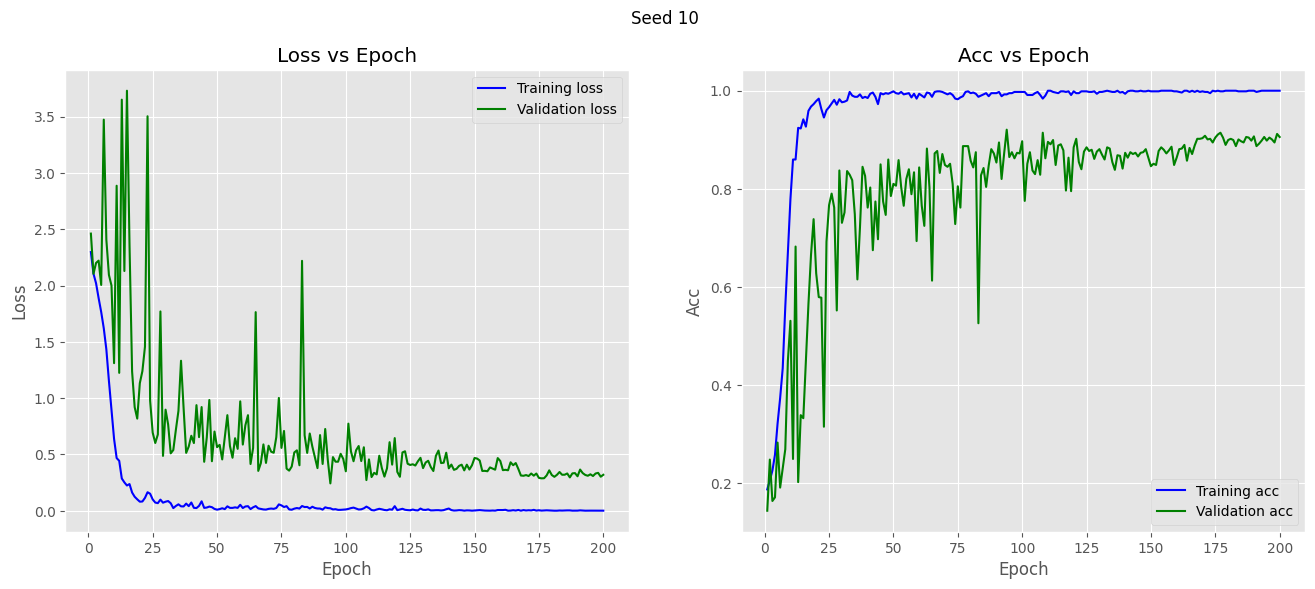

In [12]:
row, col = train_loss.shape

for i, seed in enumerate(seed_lst):
    
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize = (16, 6))
    
        ax0 = fig.add_subplot(1, 2, 1)
        ax0.plot(np.arange(1, num_epochs+1), train_loss[i, :], label = "Training loss", c = "blue")
        ax0.plot(np.arange(1, num_epochs+1), val_loss[i, :], label = "Validation loss", c = "green")
        ax0.set_title("Loss vs Epoch")
        ax0.set_xlabel("Epoch")
        ax0.set_ylabel("Loss")
        ax0.legend()
        ax0.grid(True)
        
        ax1 = fig.add_subplot(1, 2, 2)
        ax1.plot(np.arange(1, num_epochs+1), train_acc[i, :], label = "Training acc", c = "blue")
        ax1.plot(np.arange(1, num_epochs+1), val_acc[i, :], label = "Validation acc", c = "green")
        ax1.set_title("Acc vs Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Acc")
        ax1.legend()
        ax1.grid(True)

        fig.suptitle(f"Seed {seed}")
        plt.show()

In [10]:
# seed_lst = [10, 42, 100, 123, 666]
seed_lst = [10]
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    new_model = TIPSResNet18(num_classes=len(train_ds.class_to_idx), pad_type="reflect")
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/TIPS/SSR_w_noise/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs, _ = new_model(inputs)
            preds = outputs.argmax(dim=1)
            
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {100* test_acc:.4f}")
    test_acc_lst.append(test_acc)

test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Evaluating Run 0: Seed 10
Test Accuracy: 92.9499
Min: 92.9499
Max: 92.9499
Avg, Std: 92.9499, 0.0000


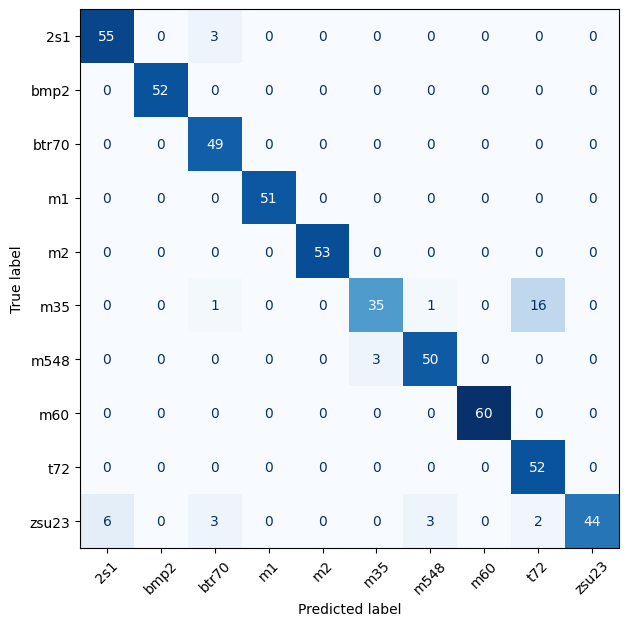

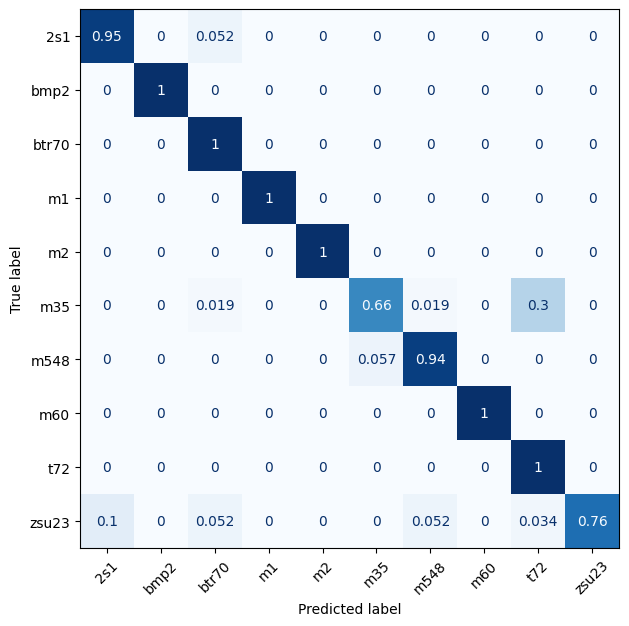

In [8]:
test_dataloader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)

seed = 10
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

new_model = TIPSResNet18(num_classes=len(train_ds.class_to_idx), pad_type="reflect")

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/TIPS/SSR_w_noise/rn18_seed{seed}_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

n_test = len(test_ds)
labels_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
preds_tensor = torch.zeros(n_test, dtype=torch.long, device=device)

idx = 0
with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs, _ = new_model(inputs)
        preds = outputs.argmax(dim=1)

        bs = inputs.size(0)
        labels_tensor[idx:idx+bs] = labels
        preds_tensor[idx:idx+bs] = preds
        idx += bs

_labels_all = labels_tensor.cpu().numpy()
_preds_all = preds_tensor.cpu().numpy()

cm = confusion_matrix(_labels_all, _preds_all)
cm_cpu = cp.asnumpy(cm)
disp = ConfusionMatrixDisplay(cm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.tick_params(axis='x', rotation=45)
plt.show()

cm_norm = confusion_matrix(_labels_all, _preds_all, normalize='true')
cm_norm_cpu = cp.asnumpy(cm_norm)
disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.tick_params(axis='x', rotation=45)
plt.show()

In [10]:
shifted_left_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = -5, axis = -1), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
shifted_right_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = 15, axis = -1), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
shifted_up_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = 10, axis = -2), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
shifted_down_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = -10, axis = -2), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

shifted_left_17 = filter_by_elev(shifted_left_meas_ds, {17})
shifted_right_17 = filter_by_elev(shifted_right_meas_ds, {17})
shifted_up_17 = filter_by_elev(shifted_up_meas_ds, {17})
shifted_down_17 = filter_by_elev(shifted_down_meas_ds, {17})

In [20]:
# seed_lst = [10, 42, 100, 123, 666]
seed_lst = [10]
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for ds in [shifted_left_17, shifted_right_17, shifted_up_17, shifted_down_17]:

    if ds is shifted_left_17:
        print("shifted left by 5 units")
    elif ds is shifted_right_17:
        print("shifted right by 15 units")
    elif ds is shifted_up_17:
        print("shifted up by 10 units")
    elif ds is shifted_down_17:
        print("shifted down by 10 units")
    
    for i, seed in enumerate(seed_lst):
        print(f"Evaluating Run {i}: Seed {seed}")
        new_model = TIPSResNet18(num_classes=len(train_ds.class_to_idx), pad_type="reflect")
        
        # Load your trained weights
        new_model.load_state_dict(torch.load(
                os.path.join(workspace, f"weights/SSR/Extras/TIPS/SSR_w_noise/rn18_seed{seed}_b16.pth"),
                map_location=device
            ))
        
        new_model = new_model.to(device)
        new_model.eval()
        
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in DataLoader(ds, batch_size=32, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
                inputs = inputs.to(device)
                labels = labels.to(device)
        
                outputs, _ = new_model(inputs)
                preds = outputs.argmax(dim = 1)
        
                correct += torch.sum(preds == labels).item()
                total += labels.size(0)
        
        test_acc = correct / total
        print(f"Test Accuracy: {100 * test_acc:.4f}")
        test_acc_lst.append(test_acc)
    print("\n")

shifted left by 5 units
Evaluating Run 0: Seed 10
Test Accuracy: 78.1076


shifted right by 15 units
Evaluating Run 0: Seed 10
Test Accuracy: 91.0946


shifted up by 10 units
Evaluating Run 0: Seed 10
Test Accuracy: 76.6234


shifted down by 10 units
Evaluating Run 0: Seed 10
Test Accuracy: 68.0891




shifted left by 5 units


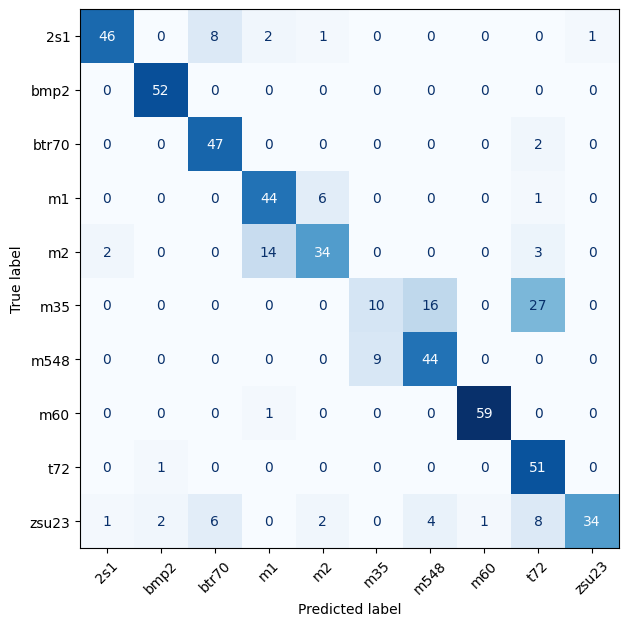

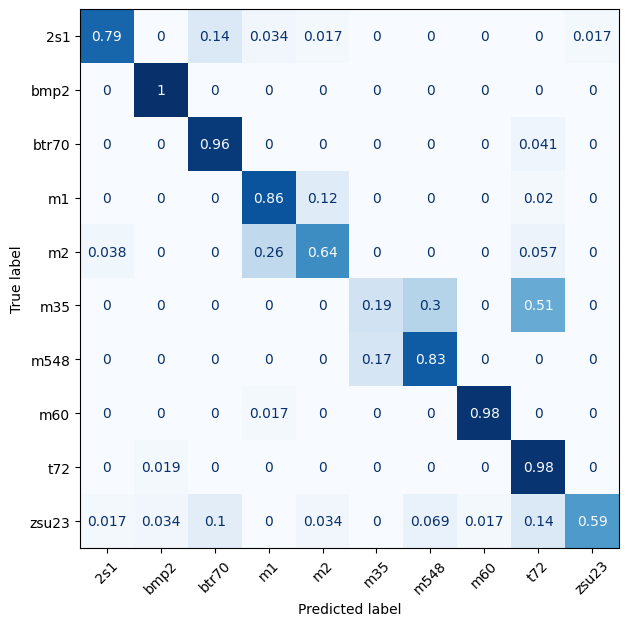

shifted right by 15 units


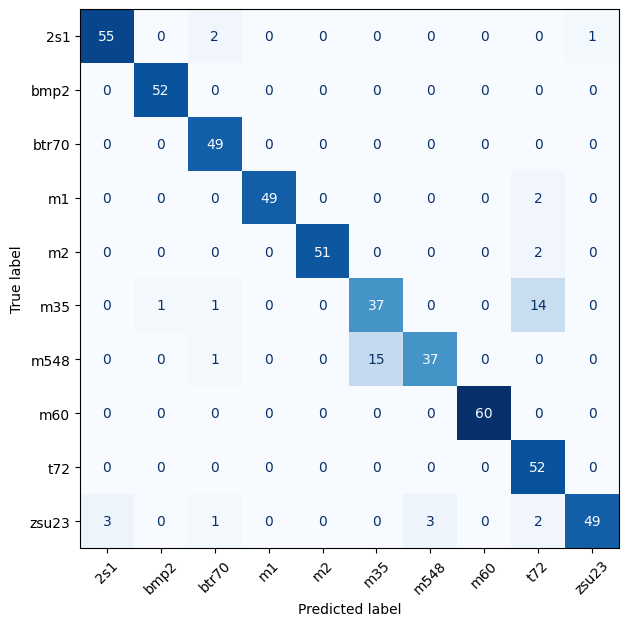

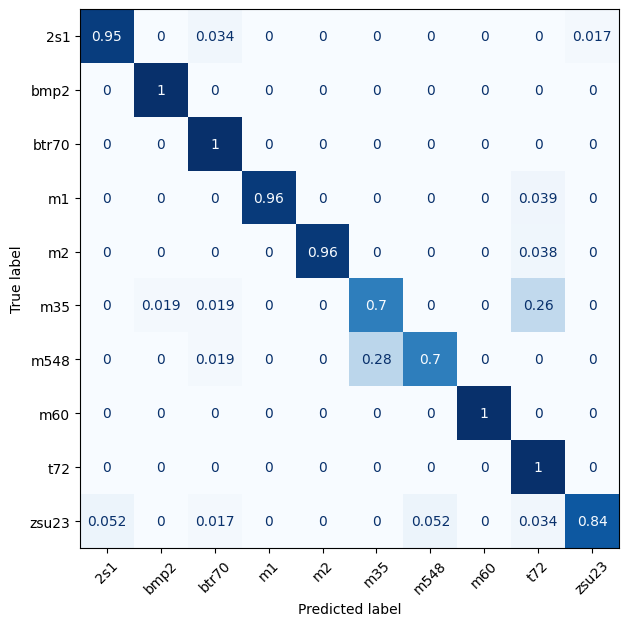

shifted up by 10 units


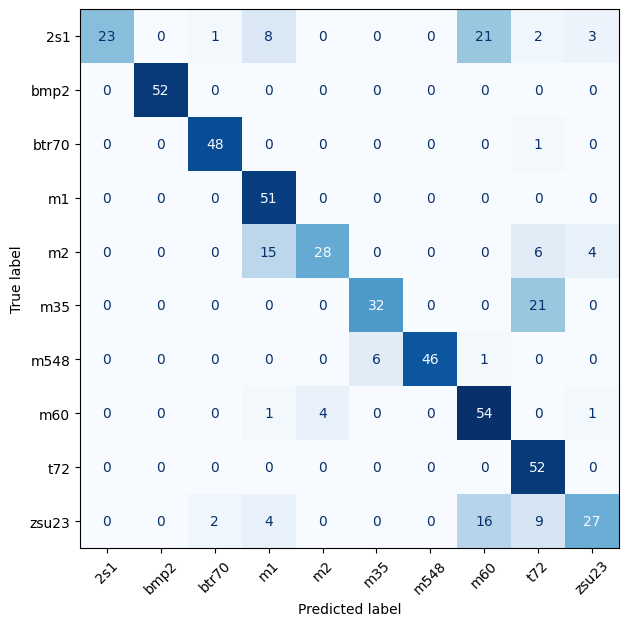

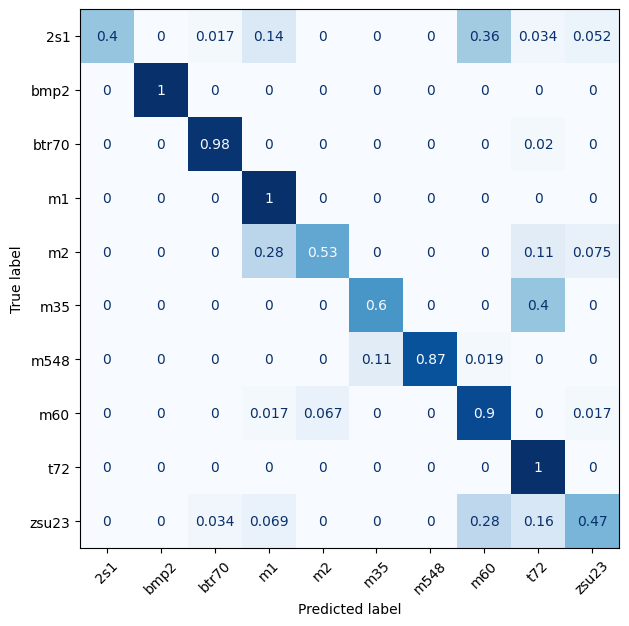

shifted down by 10 units


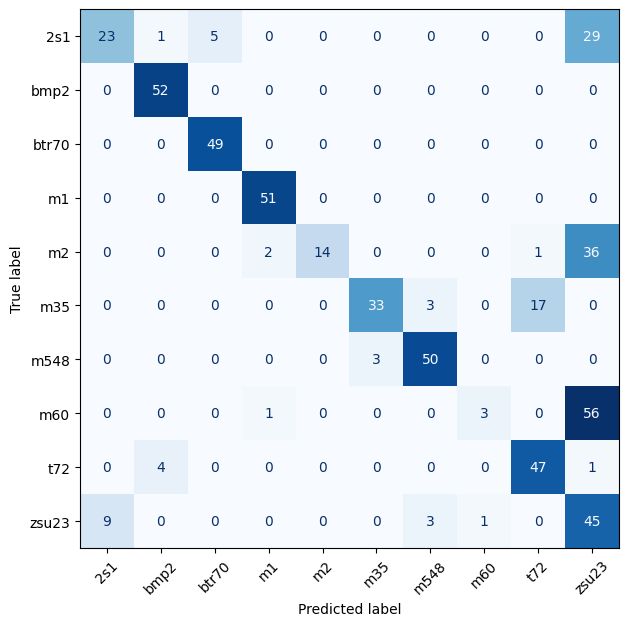

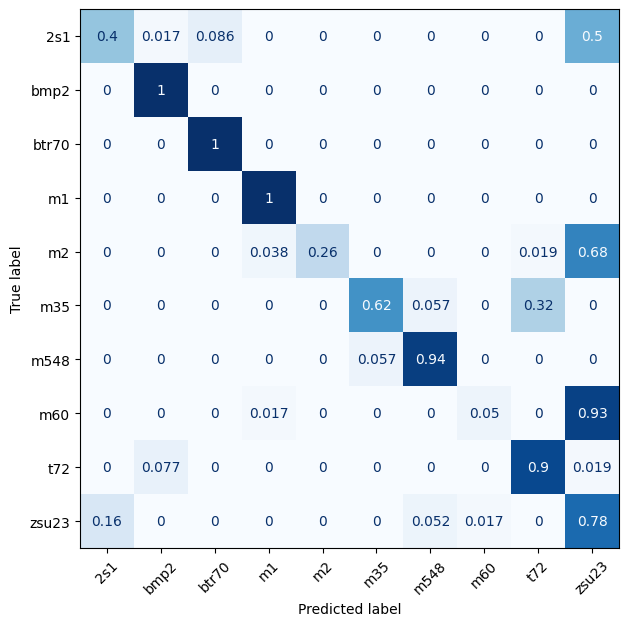

In [12]:
for ds in [shifted_left_17, shifted_right_17, shifted_up_17, shifted_down_17]:

    test_dataloader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)

    if ds is shifted_left_17:
        print("shifted left by 5 units")
    elif ds is shifted_right_17:
        print("shifted right by 15 units")
    elif ds is shifted_up_17:
        print("shifted up by 10 units")
    elif ds is shifted_down_17:
        print("shifted down by 10 units")

    seed = 10
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    new_model = TIPSResNet18(num_classes=len(train_ds.class_to_idx), pad_type="reflect")
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/TIPS/SSR_w_noise/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()
    
    n_test = len(test_ds)
    labels_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
    preds_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
    
    idx = 0
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs, _ = new_model(inputs)
            preds = outputs.argmax(dim=1)
    
            bs = inputs.size(0)
            labels_tensor[idx:idx+bs] = labels
            preds_tensor[idx:idx+bs] = preds
            idx += bs
    
    _labels_all = labels_tensor.cpu().numpy()
    _preds_all = preds_tensor.cpu().numpy()
    
    cm = confusion_matrix(_labels_all, _preds_all)
    cm_cpu = cp.asnumpy(cm)
    disp = ConfusionMatrixDisplay(cm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
    fig, ax = plt.subplots(figsize=(7, 7))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.tick_params(axis='x', rotation=45)
    plt.show()
    
    cm_norm = confusion_matrix(_labels_all, _preds_all, normalize='true')
    cm_norm_cpu = cp.asnumpy(cm_norm)
    disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
    fig, ax = plt.subplots(figsize=(7, 7))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.tick_params(axis='x', rotation=45)
    plt.show()